In [67]:
from pathlib import Path
import os
import sys
import csv

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import cvxpy as cp

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [68]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)

In [69]:
# ...existing code...
mapping_list = [
    0, 0, 0,
    "Electrode_25", "Electrode_24", "Electrode_23", "Electrode_22", "Electrode_21",
    "Electrode_19", "Electrode_18", "Electrode_17", "Electrode_16", "Electrode_15",
    0, 0, 0, 0, 0, 0,
    "Electrode_12", "Electrode_3", "Electrode_4", "Electrode_5", "Electrode_6",
    "Electrode_7", "Electrode_8", "Electrode_9", "Electrode_10", "Electrode_11",
    0, 0, 0,
]

mapping_dict = {}
for idx, value in enumerate(mapping_list, start=1):
    if value != 0:
        electrode_num = int(value.split("_")[1])
        mapping_dict[electrode_num] = idx

mapping_dict['artiq_input_num'] = len(mapping_list)

print("Total slots:", len(mapping_dict)-1)
print(mapping_dict)

import pickle
with open('mapping_data.pkl', 'wb') as f:
    pickle.dump({
        'mapping_dict': mapping_dict,
        'mapping_list': mapping_list
    }, f)

Total slots: 20
{25: 4, 24: 5, 23: 6, 22: 7, 21: 8, 19: 9, 18: 10, 17: 11, 16: 12, 15: 13, 12: 20, 3: 21, 4: 22, 5: 23, 6: 24, 7: 25, 8: 26, 9: 27, 10: 28, 11: 29, 'artiq_input_num': 32}


In [70]:
from post_process import read_post_processed
from field_analysis import analyze_dc_pot, analyze_dc_pot_0

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
excitation_electrodes = [3,4,5,6,7, 12,15, 16,17,18,19,21]
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: [3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19, 21]


In [71]:
dc_fields = {}

x0 = -250e-6
y0 = 0
z0 = 49.99e-6

dr = 1e-6

for i in excitation_electrodes:
    
    coeff, phi, grad, hessian = analyze_dc_pot(x, y, z, potentials[i], x0, y0, z0, dr)

    dc_fields[i] = (coeff, phi, grad, hessian)

#print(coeff, phi, grad, hessian)

[2.49768737e+05 1.25543191e+03 5.61860924e+05 1.01703176e+06
 1.67494084e-07 6.10891166e+01 5.37149619e+01 1.85285804e+02
 1.02497107e-02] 0.010251739 [ 59.2302148   53.85228859 186.17264304] [[ 4.99537474e+05  5.61860924e+05  1.01703176e+06]
 [ 5.61860924e+05  2.51086382e+03  1.67494084e-07]
 [ 1.01703176e+06  1.67494084e-07 -5.02048338e+05]]

## Axial set

In [72]:
from field_analysis import fit_prep, print_field, quadratic_sol

omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-4

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = np.array([-0.25]), target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))

x = jnp.linalg.lstsq(A, b, rcond=None)[0]
V_axial = x

out_csv = Path("control_voltage/Vs_axial.csv")  # saved in current working directory

from post_process import save_to_artiq

save_to_artiq(V_axial, excitation_electrodes, mapping_dict, filename=out_csv)
# with out_csv.open("w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["electrode", "voltage_V"])
#     for electrode, voltage in zip(excitation_electrodes, V_axial):
#         writer.writerow([electrode, float(voltage)])

# print(f"Saved: {out_csv.resolve()}")

Phi: -0.2499999999999929
Grad: [-1.41015882e-08 -3.29885097e-09  1.08348583e-08]
Hessian: [[ 1.63665986e+07 -6.07769834e-10 -5.35237632e-10]
 [-6.07769834e-10 -8.18329931e+06 -8.56816769e-08]
 [-5.35237632e-10 -8.56816769e-08 -8.18329931e+06]]
Delta Pos (um): [ 8.61607751e-10 -4.03119921e-10  1.32402078e-09]


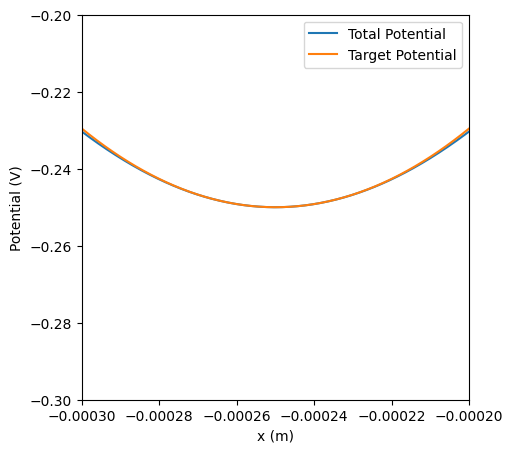

In [73]:
print_field(A @ V_axial, delta_pos=True)

potential_space = np.zeros_like(y)
coeff = V_axial
for i in range(len(coeff)):

    electrode_i = excitation_electrodes[i]
    potential_space = potential_space + coeff[i] *  potentials[electrode_i]

y0_index = np.argmin(np.abs(y_axis - y0))
z0_index = np.argmin(np.abs(z_axis - z0))
target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x_axis, potential_space[:, y0_index, z0_index], label="Total Potential")
ax.plot(x_axis,1/2*target_hessian[0,0]*(x_axis+250e-6)**2 - 0.25, label="Target Potential")
ax.set_xlim(-300e-6, -200e-6)
ax.set_ylim(-0.3, -0.2)
ax.set_xlabel("x (m)")
ax.set_ylabel("Potential (V)")
ax.legend()
#plt.savefig("axial_set.pdf")
plt.show()

Phi: -0.2499999999999929
Grad: [-1.41015882e-08 -3.29885097e-09  1.08348583e-08]
Hessian: [[ 1.63665986e+07 -6.07769834e-10 -5.35237632e-10]
 [-6.07769834e-10 -8.18329931e+06 -8.56816769e-08]
 [-5.35237632e-10 -8.56816769e-08 -8.18329931e+06]]
Delta Pos (um): [ 8.61607751e-10 -4.03119921e-10  1.32402078e-09]


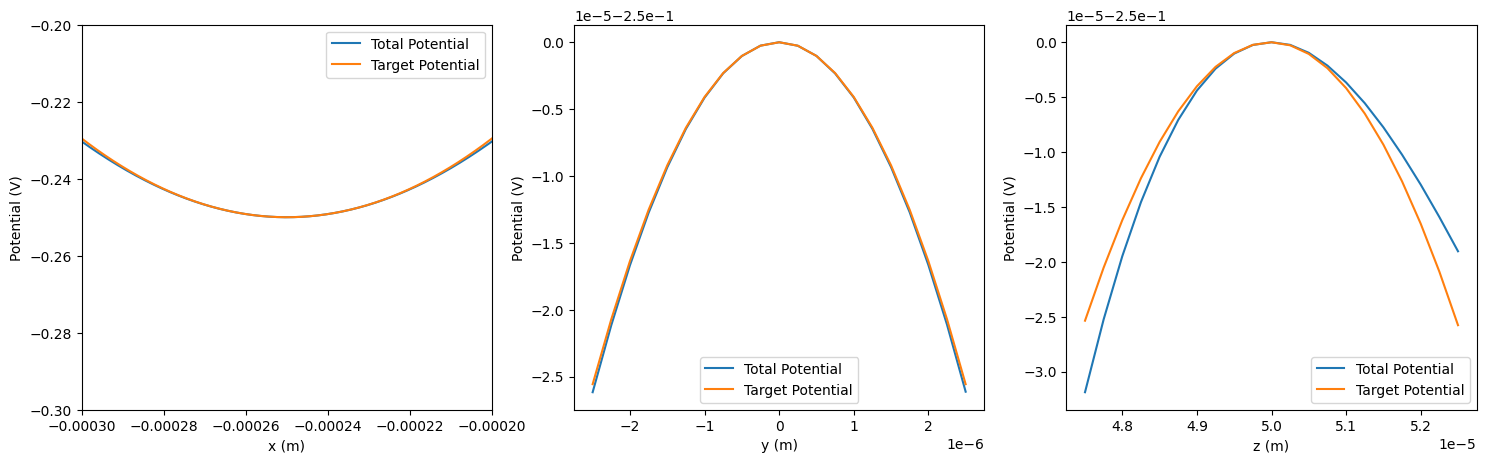

In [74]:
print_field(A @ V_axial, delta_pos=True)

potential_space = np.zeros_like(y)
coeff = V_axial
for i in range(len(coeff)):

    electrode_i = excitation_electrodes[i]
    potential_space = potential_space + coeff[i] *  potentials[electrode_i]

y0_index = np.argmin(np.abs(y_axis - y0))
z0_index = np.argmin(np.abs(z_axis - z0))
x0_index = np.argmin(np.abs(x_axis - x0))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge)

axs[0].plot(x_axis, potential_space[:, y0_index, z0_index], label="Total Potential")
axs[0].plot(x_axis,1/2*target_hessian[0,0]*(x_axis-x0)**2 - 0.25, label="Target Potential")
axs[0].set_xlim(-300e-6, -200e-6)
axs[0].set_ylim(-0.3, -0.2)
axs[0].legend()

axs[0].set_xlabel("x (m)")
axs[0].set_ylabel("Potential (V)")

axs[1].plot(y_axis, potential_space[x0_index, :, z0_index], label="Total Potential")
axs[1].plot(y_axis,1/2*target_hessian[1,1]*(y_axis-y0)**2 - 0.25, label="Target Potential")
axs[1].set_xlabel("y (m)")
axs[1].set_ylabel("Potential (V)")
axs[1].legend()

axs[2].plot(z_axis, potential_space[x0_index, y0_index, :], label="Total Potential")
axs[2].plot(z_axis,1/2*target_hessian[2,2]*(z_axis-z0)**2 - 0.25, label="Target Potential")
axs[2].set_xlabel("z (m)")
axs[2].set_ylabel("Potential (V)")
axs[2].legend()
fig.savefig(Path("control_voltage/plot/axial_set.pdf"), bbox_inches='tight')
plt.show()


## Compensation set

In [75]:
def solve_bounded_lstsq(A, b, max_abs_x=0.5, reg=1e-6):
    A_np = np.asarray(A)
    b_np = np.asarray(b).reshape(-1)
    x_var = cp.Variable(A_np.shape[1])

    objective = cp.Minimize(cp.sum_squares(A_np @ x_var - b_np) + reg * cp.sum_squares(x_var))
    constraints = [cp.abs(x_var) <= max_abs_x]
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    if x_var.value is None:
        raise RuntimeError("Constrained least-squares did not converge to a solution.")

    return np.asarray(x_var.value).reshape(-1)

In [76]:
omega = 2 * np.pi * 1e6
V_max = 0.2
c_Vk = 1e-3
omega_r = 2 * np.pi * 4e6
target_grad = np.array([-mass*omega**2/(charge) * 1e-6, 0, 0])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

V_xcomp = solve_bounded_lstsq(A, b, max_abs_x=V_max, reg=c_Vk)

out_csv = Path("control_voltage/Vs_xcomp.csv")  # saved in current working directory

save_to_artiq(V_xcomp, excitation_electrodes, mapping_dict, filename=out_csv)

# with out_csv.open("w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["electrode", "voltage_V"])
#     for electrode, voltage in zip(excitation_electrodes, V_xcomp):
#         writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/Vs_xcomp.csv


/var/folders/0t/t_n45mpd5hz903g9jhqvh76m0000gn/T/ipykernel_86758/3270101503.py:9: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.OSQP)


In [77]:
print_field(A @ (V_axial + V_xcomp), delta_pos=True)

Phi: -0.24998302845074738
Grad: [-1.53920067e+01 -1.27935351e-04 -2.42836494e-04]
Hessian: [[ 1.63665986e+07  2.42143869e-08 -7.49791984e-05]
 [ 2.42143869e-08 -8.18329931e+06 -4.84287739e-08]
 [-7.49791984e-05 -4.84287739e-08 -8.18329931e+06]]
Delta Pos (um): [ 9.40452382e-01 -1.56337128e-05 -2.96746526e-05]


In [78]:
target_grad = np.array([0, -mass*omega_r**2/(charge) * 1e-6, 0])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

V_ycomp = solve_bounded_lstsq(A, b, max_abs_x=V_max, reg=c_Vk)

out_csv = Path("control_voltage/Vs_ycomp.csv")  # saved in current working directory

save_to_artiq(V_ycomp, excitation_electrodes, mapping_dict, filename=out_csv)

# with out_csv.open("w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["electrode", "voltage_V"])
#     for electrode, voltage in zip(excitation_electrodes, V_ycomp):
#         writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/Vs_ycomp.csv


In [79]:
target_grad = np.array([0, 0, -mass*omega_r**2/(charge) * 1e-6])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

V_zcomp = solve_bounded_lstsq(A, b, max_abs_x=V_max, reg=c_Vk)

out_csv = Path("control_voltage/Vs_zcomp.csv")  # saved in current working directory

save_to_artiq(V_zcomp, excitation_electrodes, mapping_dict, filename=out_csv)

# with out_csv.open("w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["electrode", "voltage_V"])
#     for electrode, voltage in zip(excitation_electrodes, V_zcomp):
#         writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/Vs_zcomp.csv


## Tilt set

In [80]:
np.linalg.eig([[4,0.5],[0.5,4]])

EigResult(eigenvalues=array([4.5, 3.5]), eigenvectors=array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]]))

In [81]:
delta_omega = 0.5 * 2 * np.pi * 1e6
target_phi = np.array([0])
target_grad = np.array([0, 0, 0])
target_hessian = np.array([[0, 0, 0], [0, 0, mass*2*delta_omega*omega_r/(charge)], [0, mass*2*delta_omega*omega_r/(charge), 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

x = jnp.linalg.lstsq(A, b, rcond=None)[0]
V_tilt = x

out_csv = Path("control_voltage/Vs_tilt.csv")  # saved in current working directory
save_to_artiq(V_tilt, excitation_electrodes, mapping_dict, filename=out_csv)
# with out_csv.open("w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["electrode", "voltage_V"])
#     for electrode, voltage in zip(excitation_electrodes, V_tilt):
#         writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/Vs_tilt.csv


In [82]:
from field_analysis import upper_vector_to_hessian

V_sum = V_axial + V_xcomp + V_ycomp + V_zcomp + V_tilt
b = A @ V_sum

phi, grad, upper_hessian = b[0], b[1:4], b[4:]
hessian = upper_vector_to_hessian(upper_hessian)
print(hessian)

[[ 1.63665986e+07  2.24681571e-08 -7.45411412e-05]
 [ 2.24681571e-08 -8.18329931e+06  6.54663945e+07]
 [-7.45411412e-05  6.54663945e+07 -8.18329931e+06]]


In [83]:
mass*(omega_r)**2/(charge)

261865577.92812133

In [84]:
hessian = hessian + np.array([[0, 0, 0], [0, 1, 0], [0, 0, 1]]) * mass*(omega_r)**2/(charge)

In [85]:
print(hessian)

[[ 1.63665986e+07  2.24681571e-08 -7.45411412e-05]
 [ 2.24681571e-08  2.53682279e+08  6.54663945e+07]
 [-7.45411412e-05  6.54663945e+07  2.53682279e+08]]


In [86]:
print(f"Phi: {phi}")
print(f"Grad: {grad}")
print(f"Hessian: {hessian}")
print(f"Delta Pos (um): {-jnp.linalg.solve(hessian, grad)*1e6}")

Phi: -0.28001252171570745
Grad: [ -15.39200737 -261.86570568 -261.86581627]
Hessian: [[ 1.63665986e+07  2.24681571e-08 -7.45411412e-05]
 [ 2.24681571e-08  2.53682279e+08  6.54663945e+07]
 [-7.45411412e-05  6.54663945e+07  2.53682279e+08]]
Delta Pos (um): [0.94045243 0.8205131  0.82051369]


In [87]:
eigvals, eigvecs = np.linalg.eigh(hessian)
eigvals = eigvals * charge / mass
print("Secular frequencies (MHz):", np.sqrt(eigvals)/(2*np.pi*1e6))
print("Eigenvectors (principal axes):", eigvecs)

Secular frequencies (MHz): [1.         3.39116499 4.41588043]
Eigenvectors (principal axes): [[ 1.00000000e+00  3.06806244e-13 -1.74028331e-13]
 [-9.38881627e-14  7.07106781e-01  7.07106781e-01]
 [ 3.40001388e-13 -7.07106781e-01  7.07106781e-01]]


In [88]:
from field_analysis import get_pot

excitation_electrodes = [3,4,5,6,7, 12,15, 16,17,18,19,21]
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
X, Y, Z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))


coeff = V_sum

x = -250e-6
y = 0
z = 49.99e-6
dr = 1e-6


for i in range(len(coeff)):

    el= excitation_electrodes[i]
    X_p, Y_p, Z_p, potential = get_pot(X, Y, Z, potentials[el], [-254e-6, -246e-6], [-4e-6, 4e-6], [46e-6,54e-6])

    if i == 0:
        total_potential = coeff[i] *  potential
    else:
        total_potential = total_potential + coeff[i] *  potential

DC Excitation Electrodes: [3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19, 21]


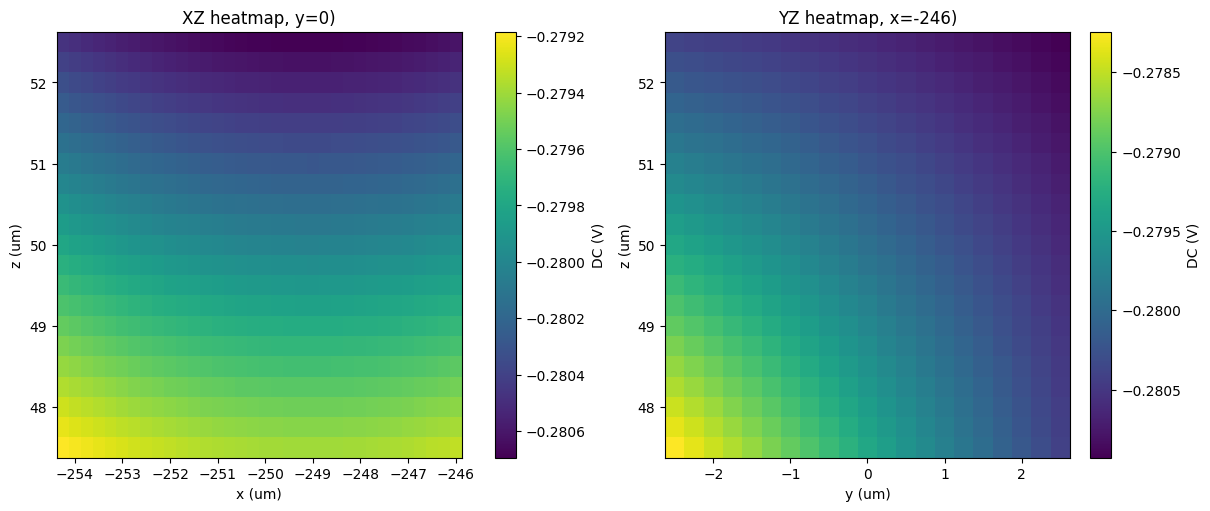

In [89]:
phi = total_potential

# Choose central slices (or closest to 0 if available).
x_axis = X_p[:, 0, 0]
y_axis = Y_p[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis - 0.0))) if np.any(np.isfinite(x_axis)) else X_p.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else Y_p.shape[1] // 2

# xz slice at fixed y
X_xz = X_p[:, y_idx, :]
Z_xz = Z_p[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = Y_p[x_idx, :, :]
Z_yz = Z_p[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="viridis")
axes[0].set_title(f"XZ heatmap, y={y_axis[y_idx]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="DC (V)")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="viridis")
axes[1].set_title(f"YZ heatmap, x={x_axis[x_idx]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="DC (V)")

plt.show()

In [90]:
print(len(X_p), len(Y_p), len(Z_p), phi.shape)

34 34 34 (34, 21, 21)


In [91]:
import h5py

with h5py.File("/Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/rf/rf_pseudo_potential.h5", "r") as f:
    xpp = f["x"][:]
    ypp = f["y"][:]
    zpp = f["z"][:]
    phi_pp = f["rf_pp"][:]

In [92]:
x_pp_clipped, y_pp_clipped, z_pp_clipped, phi_pp_clipped = get_pot(xpp, ypp, zpp, phi_pp, [-4e-6, 4e-6], [-4e-6, 4e-6], [46e-6,54e-6])

In [93]:
# ...existing code...
from scipy.interpolate import RegularGridInterpolator

# Convert xpp/ypp/zpp to 1D axes if they are meshgrid arrays
xpp_axis = xpp[:, 0, 0] - 250e-6 if np.ndim(xpp) == 3 else xpp
ypp_axis = ypp[0, :, 0] if np.ndim(ypp) == 3 else ypp
zpp_axis = zpp[0, 0, :] if np.ndim(zpp) == 3 else zpp

# Ensure axes are increasing; reorder phi_pp accordingly
ix = np.argsort(xpp_axis)
iy = np.argsort(ypp_axis)
iz = np.argsort(zpp_axis)

xpp_axis = xpp_axis[ix]
ypp_axis = ypp_axis[iy]
zpp_axis = zpp_axis[iz]
phi_pp_sorted = phi_pp[np.ix_(ix, iy, iz)]

# Build interpolator
rgi = RegularGridInterpolator(
    (xpp_axis, ypp_axis, zpp_axis),
    phi_pp_sorted,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

# Query at DC grid points (X_p, Y_p, Z_p)
query_points = np.column_stack([X_p.ravel(), Y_p.ravel(), Z_p.ravel()])
phi_pp_on_dc_grid = rgi(query_points).reshape(X_p.shape)

print("Interpolated RF pseudo-potential shape:", phi_pp_on_dc_grid.shape)
print("NaN count (outside RF grid bounds):", np.isnan(phi_pp_on_dc_grid).sum())

Interpolated RF pseudo-potential shape: (34, 21, 21)
NaN count (outside RF grid bounds): 0


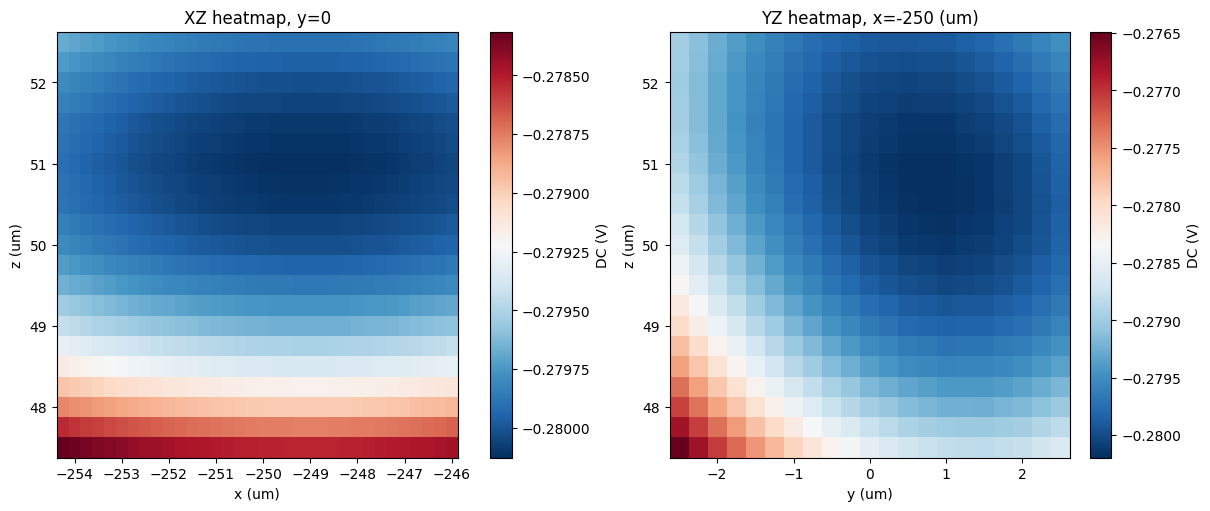

In [94]:
phi = total_potential + phi_pp_on_dc_grid

# Choose central slices (or closest to 0 if available).
x_axis = X_p[:, 0, 0]
y_axis = Y_p[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis + 250e-6))) if np.any(np.isfinite(x_axis)) else X_p.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else Y_p.shape[1] // 2

# xz slice at fixed y
X_xz = X_p[:, y_idx, :]
Z_xz = Z_p[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = Y_p[x_idx, :, :]
Z_yz = Z_p[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="RdBu_r")
axes[0].set_title(f"XZ heatmap, y={y_axis[y_idx]*1e6:.4g}")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="DC (V)")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="RdBu_r")
axes[1].set_title(f"YZ heatmap, x={x_axis[x_idx]*1e6:.4g} (um)")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="DC (V)")

fig.savefig("control_voltage/plot/total_potential.pdf", bbox_inches='tight')
plt.show()